<a href="https://colab.research.google.com/github/shaimathamer/Mapping_Test/blob/main/Reduce_Color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Define the libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

from sklearn.cluster import KMeans

from skimage.metrics import (
    structural_similarity as ssim,
    mean_squared_error,
    peak_signal_noise_ratio
)

Step 2 — Upload the JPG

In [3]:
uploaded = files.upload()

Saving Screenshot 2026-08-15 221539.png to Screenshot 2026-08-15 221539.png


In [4]:
filename = list(uploaded.keys())[0]

print("Uploaded image:", filename)

Uploaded image: Screenshot 2026-08-15 221539.png


Step 3 — Load the image as RGB

In [5]:
image = Image.open(filename).convert("RGB")

image = np.array(image)

print("Image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum value:", image.min())
print("Maximum value:", image.max())

Image shape: (370, 562, 3)
Data type: uint8
Minimum value: 0
Maximum value: 255


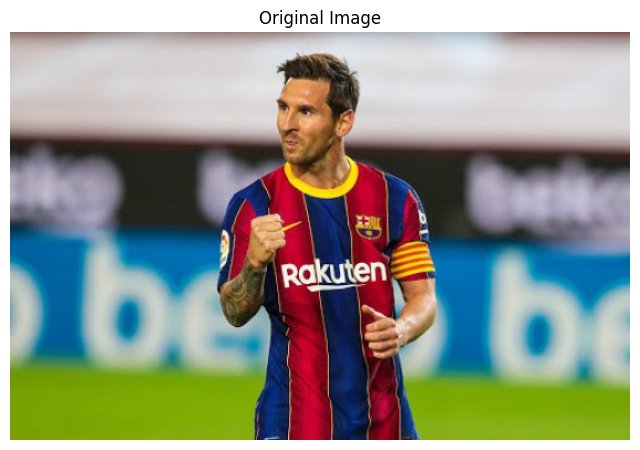

In [6]:
plt.figure(figsize=(8, 6))

plt.imshow(image)

plt.title("Original Image")
plt.axis("off")

plt.show()

Since oure goal is group similar colors together and replace each group with one representative color to reduce color taking in considration quailty loss so I considered different approaches for color reduction, including K-means, MiniBatch K-means, hierarchical clustering, Gaussian mixture models, density-based methods, and traditional color-quantization approaches such as median-cut.

For this task, I selected K-means because each RGB pixel can naturally be represented as a three-dimensional vector, and K-means directly groups similar RGB values into a predefined number of representative colors. It is also simple, reproducible, and allows the number of output colors to be explicitly controlled.

Rather than selecting the number of clusters arbitrarily, I evaluate several values of K and compare the reconstructed images using quantitative image-quality metrics. The final number of colors is selected by balancing strong color reduction against preservation of visual quality.

Step 4 Count pixels and original colors

In [7]:
height, width, channels = image.shape

total_pixels = height * width

unique_colors = np.unique(
    image.reshape(-1, 3),
    axis=0
)

original_unique_colors = len(unique_colors)

print("Height:", height)
print("Width:", width)
print("Channels:", channels)
print("Total pixels:", total_pixels)
print("Original unique colors:", original_unique_colors)

Height: 370
Width: 562
Channels: 3
Total pixels: 207940
Original unique colors: 92293


Step 5 Convert the image into RGB samples

In [8]:
pixels = image.reshape(-1, 3).astype(np.float32)

print("Original image shape:", image.shape)
print("Pixel matrix shape:", pixels.shape)

print("\nFirst 10 pixels:")
print(pixels[:10])

Original image shape: (370, 562, 3)
Pixel matrix shape: (207940, 3)

First 10 pixels:
[[137. 108. 104.]
 [136. 108. 104.]
 [138. 110. 106.]
 [138. 110. 106.]
 [138. 109. 106.]
 [137. 109. 106.]
 [137. 109. 106.]
 [137. 109. 106.]
 [137. 108. 106.]
 [137. 108. 106.]]


Step 7 Create a training sample

In [9]:
max_training_pixels = 100000

if len(pixels) > max_training_pixels:

    np.random.seed(42)

    sample_indices = np.random.choice(
        len(pixels),
        max_training_pixels,
        replace=False
    )

    training_pixels = pixels[sample_indices]

else:

    training_pixels = pixels


print("Total pixels:", len(pixels))
print("Pixels used to train K-means:", len(training_pixels))

Total pixels: 207940
Pixels used to train K-means: 100000


Step 8 Define our candidate numbers of colors

In [10]:
k_values = [4, 8, 16, 32, 64]

print("K values to test:", k_values)

K values to test: [4, 8, 16, 32, 64]


In [11]:
def reduce_colors(pixels, training_pixels, image_shape, k):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Learn k points
    model.fit(training_pixels)

    # now will assign each pixel to k
    labels = model.predict(pixels)

    # RGB values to center
    centers = model.cluster_centers_

    # now will start reduce and replace
    reduced_pixels = centers[labels]

    # Keep RGB values inside 0-255
    reduced_pixels = np.clip(
        reduced_pixels,
        0,
        255
    ).astype(np.uint8)

    # Restore image dimensions
    reduced_image = reduced_pixels.reshape(image_shape)

    return reduced_image, centers

step 9 Test several K values and measure quality

In [16]:
results = []
reduced_images = {}

for k in k_values:

    print(f"Processing K = {k}")

    reduced_image, centers = reduce_colors(
        pixels,
        training_pixels,
        image.shape,
        k
    )

    reduced_images[k] = reduced_image

    # Structural similarity
    ssim_value = ssim(
        image,
        reduced_image,
        channel_axis=-1,
        data_range=255
    )

    # Mean squared error
    mse_value = mean_squared_error(
        image,
        reduced_image
    )

    # Peak signal-to-noise ratio
    psnr_value = peak_signal_noise_ratio(
        image,
        reduced_image,
        data_range=255
    )

    color_reduction = (
        1 - k / original_unique_colors
    ) * 100

    results.append({
        "K": k,
        "SSIM": ssim_value,
        "PSNR": psnr_value,
        "MSE": mse_value,
        "Color Reduction (%)": color_reduction
    })

Processing K = 4
Processing K = 8
Processing K = 16
Processing K = 32
Processing K = 64


1-SSIM — Structural Similarity,
Closer to 1 → more similar
Lower       → more information changed,
2-MSE — Mean Squared Error -low is better
3-PSNR — Peak Signal-to-Noise Ratio evaluates reconstruction quality.more is better

In [18]:
results_df = pd.DataFrame(results)

results_df

,K,SSIM,PSNR,MSE,Color Reduction (%)
0,4,0.621134,18.110968,1004.577734,99.995666
1,8,0.697996,22.430282,371.579834,99.991332
2,16,0.788017,25.799496,171.053038,99.982664
3,32,0.848112,28.661412,88.499160,99.965328
4,64,0.896834,31.475889,46.290454,99.930656


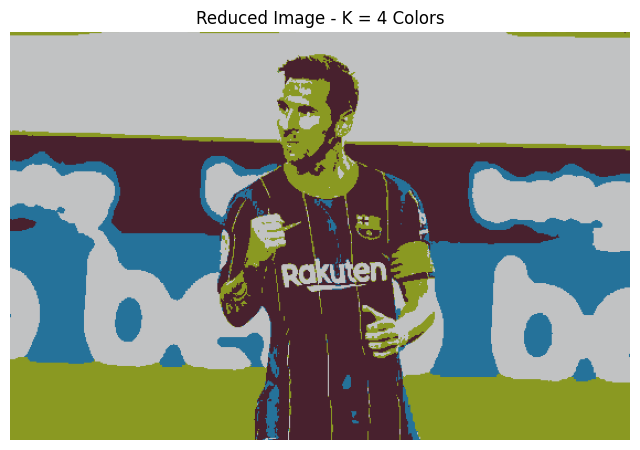

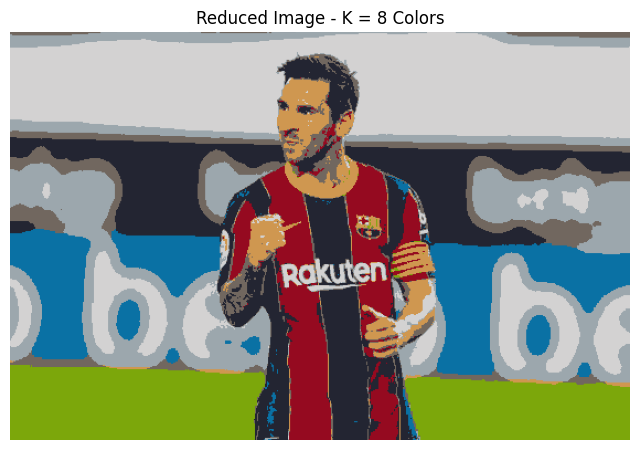

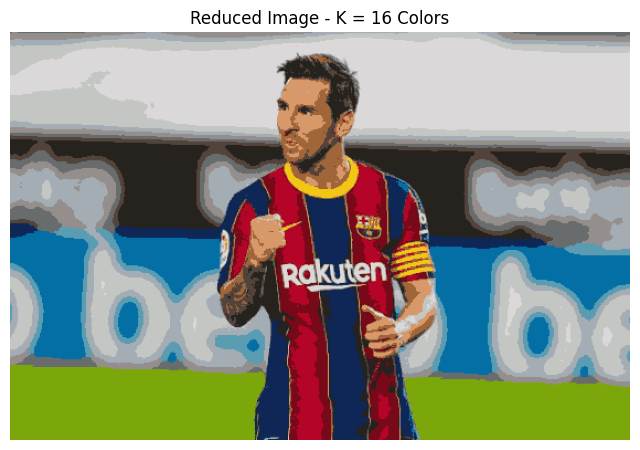

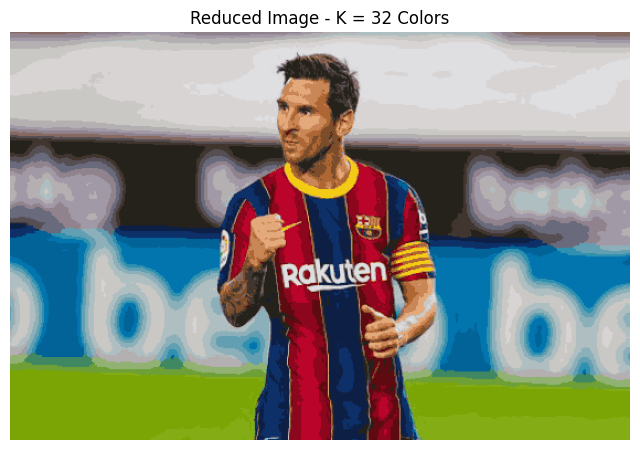

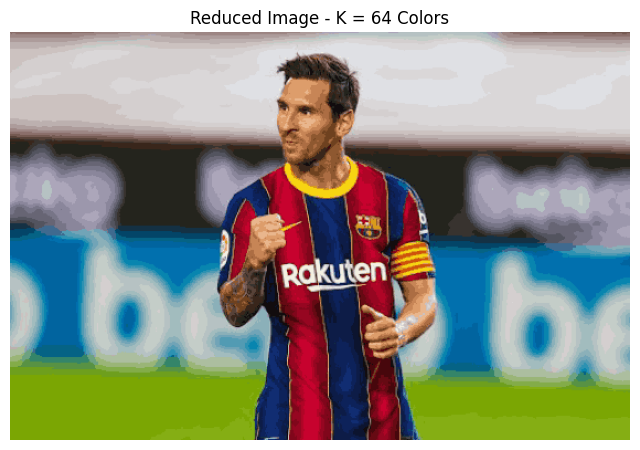

In [19]:
for k in k_values:

    plt.figure(figsize=(8, 6))

    plt.imshow(reduced_images[k])

    plt.title(f"Reduced Image - K = {k} Colors")
    plt.axis("off")

    plt.show()

Plot quality versus number of colors

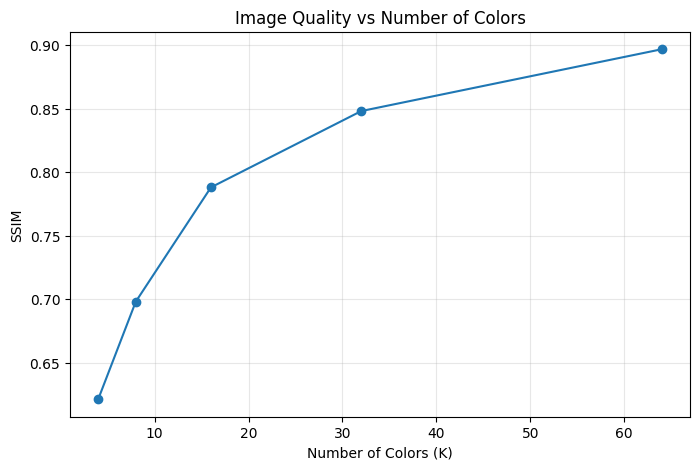

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["SSIM"],
    marker="o"
)

plt.xlabel("Number of Colors (K)")
plt.ylabel("SSIM")
plt.title("Image Quality vs Number of Colors")

plt.grid(alpha=0.3)

plt.show()

In [21]:
results_df["SSIM Improvement"] = (
    results_df["SSIM"].diff()
)

results_df

,K,SSIM,PSNR,MSE,Color Reduction (%),SSIM Improvement
0,4,0.621134,18.110968,1004.577734,99.995666,NaN
1,8,0.697996,22.430282,371.579834,99.991332,0.076861
2,16,0.788017,25.799496,171.053038,99.982664,0.090021
3,32,0.848112,28.661412,88.499160,99.965328,0.060095
4,64,0.896834,31.475889,46.290454,99.930656,0.048723


In [30]:
selected_k = 16

In [28]:
final_image = reduced_images[selected_k]

print("Selected K:", selected_k)

Selected K: 32


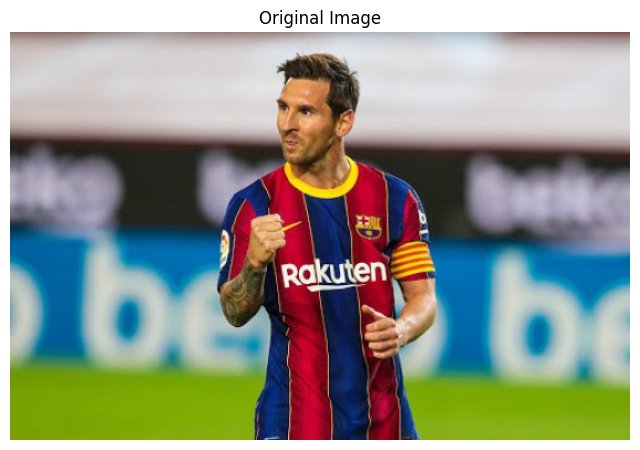

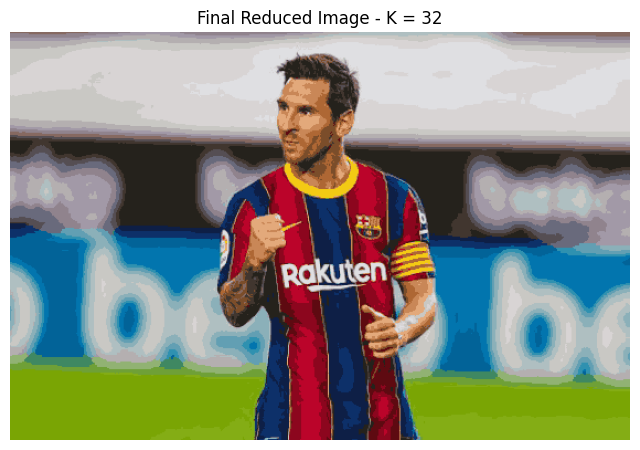

In [29]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()


plt.figure(figsize=(8, 6))

plt.imshow(final_image)
plt.title(f"Final Reduced Image - K = {selected_k}")
plt.axis("off")
plt.show()

Conclusion

The objective of this analysis was to reduce the number of colors in the image while preserving as much visual quality as possible.

I applied K-means color quantization using different numbers of clusters (K = 4, 8, 16, 32, and 64). For each value of K, I reconstructed the image and evaluated the quality using SSIM, PSNR, and MSE. The results showed that image quality improved as the number of clusters increased.

Based on the quantitative evaluation, K = 32 and K = 64 produced the best reconstruction quality among the tested values. Both achieved high similarity with the original image, while K = 64 provided only a relatively small additional improvement compared with K = 32.

I then performed a visual validation by comparing the reconstructed images with the original image. The image produced with K = 32 preserved the main colors, structures, and visual details very similarly to the K = 64 result.

For this reason, I selected **K = 32** as the final number of colors. It provides a good trade-off between reducing the color palette and maintaining image quality. Increasing the number of colors to 64 adds more complexity to the palette without providing a visually important improvement.

Therefore, the final decision was based on both quantitative validation using image-quality metrics and  qualitative human visual inspection**, rather than selecting the number of clusters arbitrarily.